# TASK 1: UNDERSTAND THE PROBLEM STATEMENT

In [2]:
# In this task, we will try to predict whether a patient has kyphosis or not. Kyphosis is an abnormally excessive convex curvature of the spine. The
# kyphosis data frame has 81 rows and 4 columns, representing data on children who have had corrective spinal surgery. Dataset contains 3 inputs and 1
# output.

# INPUTS
    # Age: in months
    # Number: the number of vertebrae invovled
    # Start: the number of the first (topmost) vertebra operated on.

# OUTPUTS
    # Kyphosis: a factor with levels "absent" or "present" indicating if a kyphosis (a type of deformation) was present after the operation.

# The objective of this project is to predict whether a patient has kyphosis or not, given their features and diagnostic measurements such as age and
# number of vertebrae as well.

# Link to dataset: https://www.kaggle.com/datasets/abbasit/kyphosis-dataset

# TASK #2: IMPORT LIBRARIES AND DATASETS


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from jupyterthemes import jtplot
jtplot.style(theme='monokai', context='notebook', ticks=True, grid=False) 
# setting the style of the notebook to be monokai theme  
# this line of code is important to ensure that we are able to see the x and y axes clearly
# If you don't run this code line, you will notice that the xlabel and ylabel on any plot is black on black and it will be hard to see them. 


In [5]:
kyphosis_df = pd.read_csv('kyphosis.csv')

In [6]:
kyphosis_df

,Kyphosis,Age,Number,Start
0,absent,71,3,5
1,absent,158,3,14
2,present,128,4,5
3,absent,2,5,1
4,absent,1,4,15
...,...,...,...,...
76,present,157,3,13
77,absent,26,7,13
78,absent,120,2,13
79,present,42,7,6


In [7]:
# What we see here is the 'Kyphosis' which indicates either absent or present. Think of it as more of a binary output, either there is a kyphosis
# disease or not. Also, we have the 'Age'. Note that 'Age' column is listed in months thats why you see the numbers are quite high. We also have the
# 'Number' column and we have the 'Start' column as well.

In [8]:
kyphosis_df.tail(7)

,Kyphosis,Age,Number,Start
74,absent,11,3,15
75,absent,178,4,15
76,present,157,3,13
77,absent,26,7,13
78,absent,120,2,13
79,present,42,7,6
80,absent,36,4,13


In [9]:
kyphosis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Kyphosis  81 non-null     object
 1   Age       81 non-null     int64 
 2   Number    81 non-null     int64 
 3   Start     81 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 2.7+ KB


In [10]:
# What we have here is the summary of the information about our dataframe. Seems like we have 81 entries ranges from 0 to 80. We have 4 columns in
# total, including their data types. Overall, the memory usage is around 2.7kb.

- **List the average, minimum and maximum age (in years) considered in this study using two different methods**

In [12]:
kyphosis_df['Age'].mean()/12

6.97119341563786

In [13]:
kyphosis_df['Age'].min()/12

0.08333333333333333

In [14]:
kyphosis_df['Age'].max()/12

17.166666666666668

In [15]:
kyphosis_df.describe()

,Age,Number,Start
count,81.000000,81.000000,81.000000
mean,83.654321,4.049383,11.493827
std,58.104251,1.619423,4.883962
min,1.000000,2.000000,1.000000
25%,26.000000,3.000000,9.000000
50%,87.000000,4.000000,13.000000
75%,130.000000,5.000000,16.000000
max,206.000000,10.000000,18.000000


# TASK #3: PERFORM DATA VISUALIZATION

In [17]:
# In this task, what i wanted to do is first convert the 'Kyphosis' column. Instead of having it with absent and present, let's convert it into simply
# zeros and ones, just binary information.

In [18]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
LabelEncoder_y = LabelEncoder()
kyphosis_df['Kyphosis'] = LabelEncoder_y.fit_transform(kyphosis_df['Kyphosis'])

In [19]:
kyphosis_df

,Kyphosis,Age,Number,Start
0,0,71,3,5
1,0,158,3,14
2,1,128,4,5
3,0,2,5,1
4,0,1,4,15
...,...,...,...,...
76,1,157,3,13
77,0,26,7,13
78,0,120,2,13
79,1,42,7,6


In [20]:
# Now we were able to overwrite the 'Kyphosis' column and we put a bunch of zeros and ones instead of having absent and present that we had before. Now,
# lets create two dataframes, one of them that essentially contains kyphosis class as true and the other one that includes kyphosis disease as false. 

In [21]:
kyphosis_True = kyphosis_df[kyphosis_df['Kyphosis']==1]

In [22]:
kyphosis_False = kyphosis_df[kyphosis_df['Kyphosis']==0]

In [23]:
print( 'Disease present after operation percentage =', (len(kyphosis_True) / len(kyphosis_df) )*100,"%")

Disease present after operation percentage = 20.98765432098765 %


In [24]:
# What we get is around 20% meaning that 20% of our data set belong to class number 1.

<Axes: >

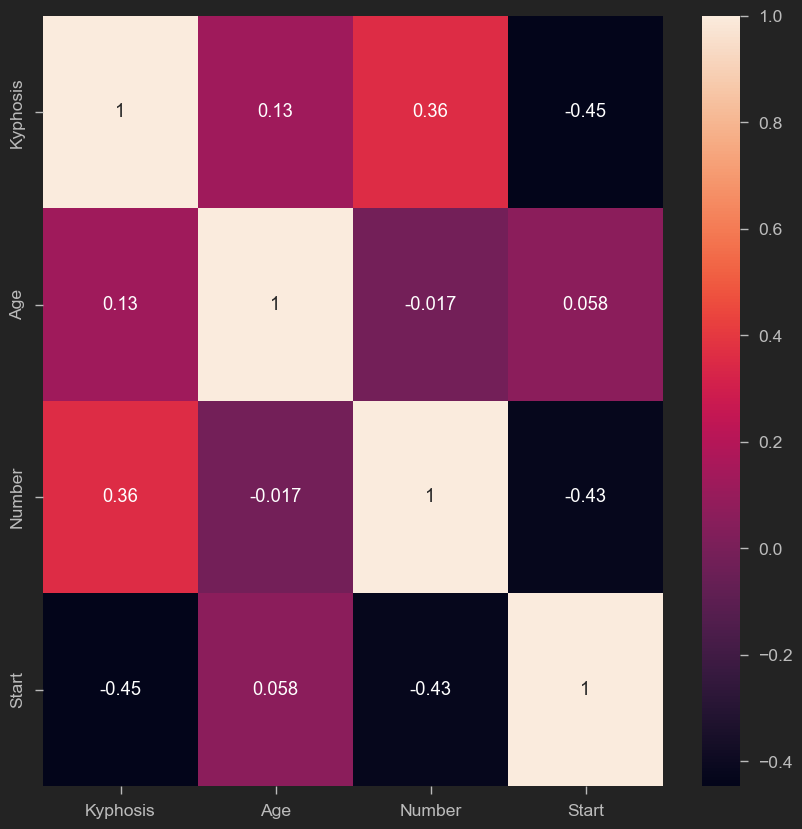

In [25]:
plt.figure(figsize=(10,10)) 
sns.heatmap(kyphosis_df.corr(), annot = True)

In [26]:
# It looks like there is barely any correlations between our features. If we can recall from any math or statistics class, for us to have a positive
# correlation, we should have a number that is very close to 1. If we dont have any correlation, we should be able to see zeros and it looks like there
# is barely any correlation between features except for the number and start, there is a little bit of like negative or inverse correlation in here.

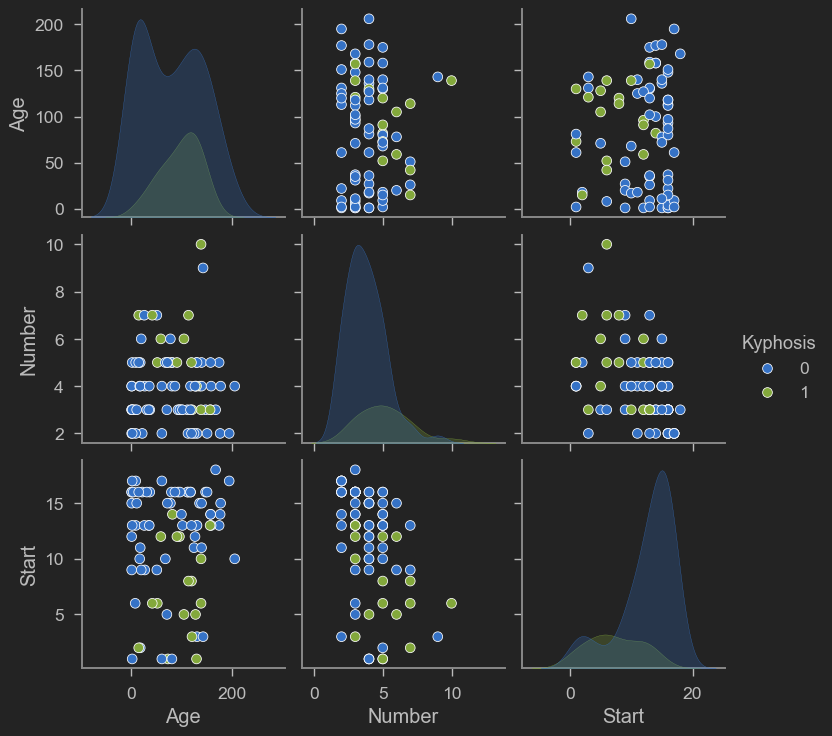

In [27]:
sns.pairplot(kyphosis_df, hue = 'Kyphosis')

In [28]:
# What we see here is now we have the same plot as before, but its color code, indicating whether the class zero or class one exists, which either
# absent or present. And again, it looks like this data is not linearly separable. Its actually quite complex data and it's really hard to separate the
# two classes from each other. Also, that would be a little bit challenging for us afterwards whenever we train our machine learning model in the future
# tasks.

- **Plot the data countplot showing how many samples belong to each class**

<Axes: xlabel='Kyphosis', ylabel='count'>

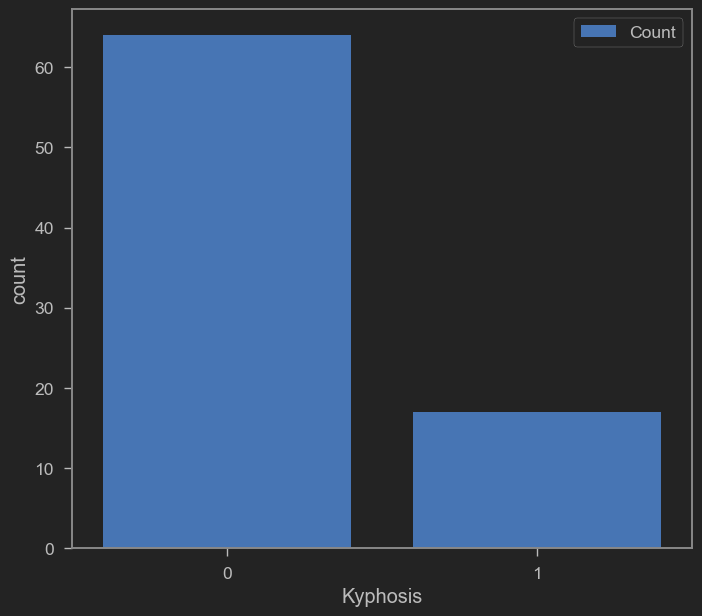

In [30]:
sns.countplot(x = kyphosis_df['Kyphosis'], label = "Count")

In [31]:
# Basically, we have around 65 samples approximately that belong to class number 0, adn we have around maybe 15 samples that belong to class number 1,
# which of course looks like we have an unbalanced dataset that we're going to use in this project.

# TASK #4: CREATE TESTING AND TRAINING DATASET/DATA CLEANING

In [33]:
# Let's drop the target label coloumns
X = kyphosis_df.drop(['Kyphosis'], axis = 1)
y = kyphosis_df['Kyphosis']

In [34]:
X

,Age,Number,Start
0,71,3,5
1,158,3,14
2,128,4,5
3,2,5,1
4,1,4,15
...,...,...,...
76,157,3,13
77,26,7,13
78,120,2,13
79,42,7,6


In [35]:
y

0     0
1     0
2     1
3     0
4     0
     ..
76    1
77    0
78    0
79    1
80    0
Name: Kyphosis, Length: 81, dtype: int32

In [36]:
# Basically, whenever we train any machine learning model or any AI model, we take our data and then we split it into 80% approximately for training and
# 20% approximately to do the testing. So the majority of the data are being used to train our model and then once the model is trained, we assess the
# performance of our model on new dataset(testing dataset) that the model has never seen before during training and thats the idea. We want to make sure
# that the model is able to generalize and not memorize the training dataset.

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [39]:
X_train.shape

(64, 3)

In [40]:
X_test.shape

(17, 3)

In [41]:
# from sklearn.preprocessing import StandardScaler
# sc = StandardScaler()
# X_train = sc.fit_transform(X_train)
# X_test = sc.transform(X_test)


In [42]:
# What we have here is an additional code but its commented out. Basically, we might need to scale our data. But since we are going to train a logistic
# regression classifier model, we actually dont need to do that scaling. The scaling would be really important if we are going to train an AI model
# within keras or a deep neural network model, because we need to make sure that all the features being fed to the model are of the same scale to make
# sure that not a single feature is kind of dominating other features. Thats why i commented it out, but just in case at the end, maybe we use a new
# algorithm or build a deep neural network model, make sure to enable the line of code above.

# TASK #5: TRAIN A LOGISTIC REGRESSION CLASSIFIER MODEL

In [44]:
# Logistic Regression is a supervised machine learning model commonly used for binary classification problems. Despite its name, it is a classification
# algorithm rather than a regression model. Its main purpose is to predict the probability that an input belongs to a certain class. Intuitively,
# Logistic Regression works by finding a line (or hyperplane) that best separates two classes. Instead of predicting continuous values, it passes a
# linear combination of the input features through a sigmoid function, which squeezes the output into a range between 0 and 1. This value is interpreted
# as the probability of belonging to the positive class. From a theoretical perspective, Logistic Regression is based on maximum likelihood estimation.
# The model learns parameters that maximize the likelihood of observing the given labels. It uses a log-loss (cross-entropy loss) function to penalize
# incorrect predictions, especially those made with high confidence. A threshold (usually 0.5) is then applied to convert probabilities into class
# labels. Logistic Regression is simple, fast, and easy to interpret, making it useful as a baseline model. However, it assumes a linear relationship
# between features and the log-odds of the outcome, which limits its ability to capture complex patterns. Still, it remains a strong and reliable method
# for many real-world classification tasks.

In [45]:
X_train.shape

(64, 3)

In [46]:
y_train.shape

(64,)

In [47]:
X_test.shape

(17, 3)

In [48]:
y_test.shape

(17,)

In [49]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

# TASK #6: EVALUATE TRAINED MODEL PERFORMANCE 

In [51]:
from sklearn.metrics import classification_report, confusion_matrix

<Axes: >

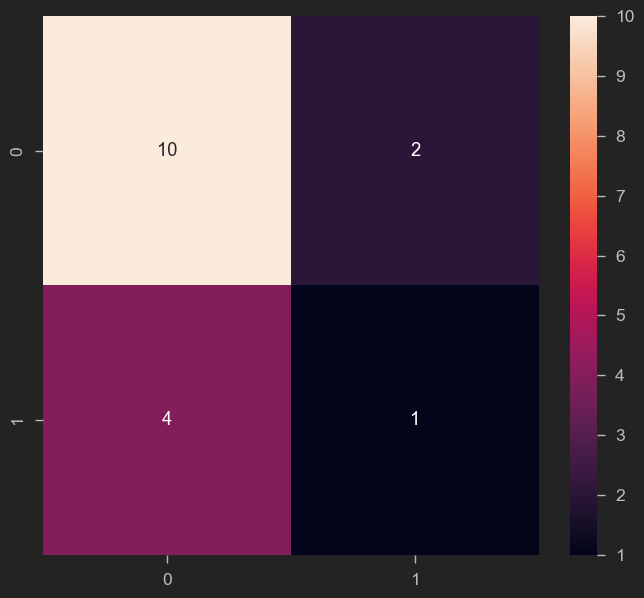

In [52]:
# Predicting the Test set results
y_predict_test = model.predict(X_test)
cm = confusion_matrix(y_test, y_predict_test)
sns.heatmap(cm, annot = True)

# Basically, what we are doing here is take our trained model, apply the predict method on it, pass along the X_test, which is the input and that will
# generate the output, which is the y_predict_test. Then next, call cm which is the confusion matrix of y_test and y_predict_test, comparing both. So,
# what we are doing here is comparing what the model generated vs. what actually happened in real life. And, if the model predictions match what
# happened in the testing dataset, that means the model actually is pretty accurate. If there's any discrepancy between the two, if there is any
# conflict between these two, that means the model predictions are off and there is misclassification error and the confusion matrix is
# gonna show the performance of the classified model.

In [53]:
# What we can see here is that the model did pretty good overall. The model was able to classify 10 samples on class 0, and 1 sample on class 1. And the
# model was able to misclassify 6 samples in total, 4 and 2.

# Another way of reading the confusion matrix is as follows. When we plot the confusion matrix on the rows, we put the model predictions and on the
# columns we put what actually happens in real life, the ground truth. If the model predictions match what happened in real life, thats a great thing.
# For example, if the model predicted zero class and in real life, that data point was actually belonging to the zero class, thats a good thing. If the
# model predicted one and in real life the true class was actually one as well, thats when the model actually get the values right. We have a total of
# 11 correctly classified samples. Now, to the troubles, if the model predicted zero, and in real life the true class was actually one. That means there
# is an error. Same when the model predicted one, while in real life it is zero. So the overall accuracy is 11 divided by 17 which is the overall number
# of samples.

In [54]:
print(classification_report(y_test, y_predict_test))

              precision    recall  f1-score   support

           0       0.71      0.83      0.77        12
           1       0.33      0.20      0.25         5

    accuracy                           0.65        17
   macro avg       0.52      0.52      0.51        17
weighted avg       0.60      0.65      0.62        17



In [55]:
# What we see here is the overall accuracy of our model which is 0.65 which is not that good. We can also see the overall precision and recall,
# precision is 0.71 on class 0, and 0.33 on class 1. The recall is 0.83, on class zero and 0.20 on class 1. And then we also have the F-1 score which is
# the harmonic mean between the precision and recall, we have achieved 0.77 and 0.25.

# TASK #7: UNDERSTAND THE THEORY AND INTUITION BEHIND DECISION TREES AND RANDOM FOREST CLASSIFIER MODELS

In [57]:
# Decision Trees and Random Forests are popular machine learning models used for classification because they are easy to understand and perform well on
# many datasets. A Decision Tree works by breaking a problem into a series of simple decisions. At each step, the model asks a question about a feature
# and splits the data based on the answer. This process continues until a final decision or class label is reached. The goal of each split is to make
# the data in each group as pure as possible, meaning most of the samples belong to the same class. Because decision trees follow a logical
# question-and-answer structure, they are easy to interpret and visualize. However, decision trees have a weakness: they can easily overfit the data.
# Small changes in the training data may lead to a very different tree, which can reduce performance on new, unseen data. A Random Forest improves upon
# decision trees by combining many trees instead of using just one. Each tree is trained on a random subset of the data and considers only a random
# subset of features when making splits. The final prediction is made by taking a majority vote from all trees. This approach reduces overfitting and
# makes the model more stable and accurate. In summary, decision trees are simple and easy to explain, while random forests are more powerful and
# reliable. Together, they show how combining multiple simple models can lead to better overall predictions.

# TASK #8: IMPROVE THE MODEL 

In [59]:
from sklearn.tree import DecisionTreeClassifier
decision_tree = DecisionTreeClassifier()
decision_tree.fit(X_train, y_train)

DecisionTreeClassifier()

<Axes: >

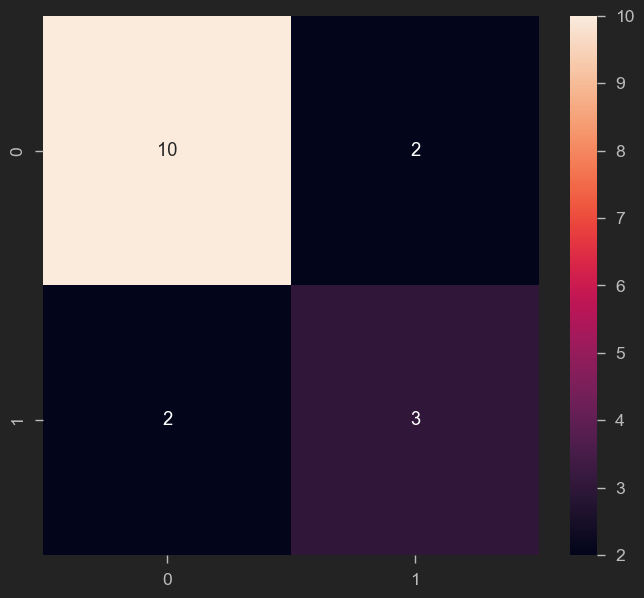

In [60]:
# Predicting the Test set results
y_predict_test = decision_tree.predict(X_test)
cm = confusion_matrix(y_test, y_predict_test)
sns.heatmap(cm, annot=True)

In [61]:
print(classification_report(y_test, y_predict_test))

              precision    recall  f1-score   support

           0       0.83      0.83      0.83        12
           1       0.60      0.60      0.60         5

    accuracy                           0.76        17
   macro avg       0.72      0.72      0.72        17
weighted avg       0.76      0.76      0.76        17



In [62]:
# So, our new model correcly classify 10 and 3 samples, so 13 samples in total. And the model was able to misclassify 2 and 2 samples, which is 4 in
# total. Also, we have been able to achieve an overall accuracy of around 76% approximately. It looks like the performance of the model improves
# dramatically compared to the logistic regression classifier model that we had above. Before we have an accuracy of 65% but now, we have an accuracy of
# 76%.

In [63]:
feature_importances = pd.DataFrame(decision_tree.feature_importances_,
                                   index = X_train.columns,
                                    columns=['importance']).sort_values('importance',ascending=False)

print(feature_importances)

        importance
Age       0.526149
Number    0.251629
Start     0.222222


In [64]:
# This kind of tell us which input is the most critical one. What we see here is that 'Age' is the most important one which stands at 0.46 followed by
# the 'Start' column and then the last one or the least improtant feature is the number.

- **Train a random forest classifier model and assess its performance**
- **Plot the confusion matrix**
- **Print the classification Report**

In [66]:
from sklearn.ensemble import RandomForestClassifier
RandomForest = RandomForestClassifier()
RandomForest.fit(X_train, y_train)

RandomForestClassifier()

<Axes: >

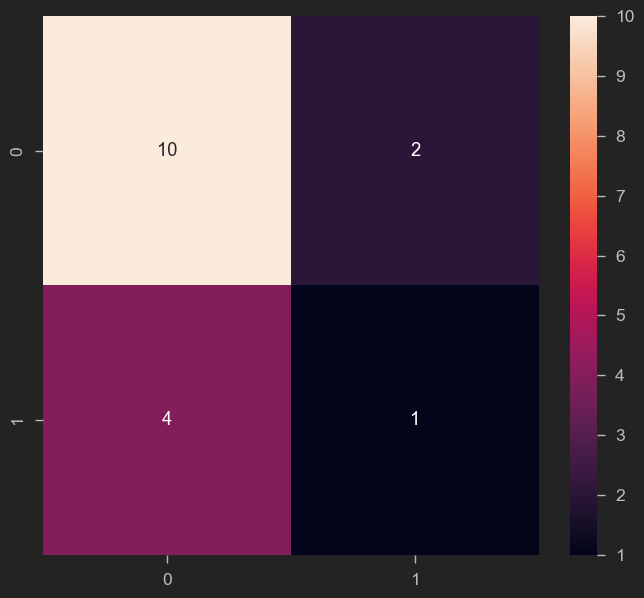

In [67]:
# Predicting the Test set results
y_predict_test = RandomForest.predict(X_test)
cm = confusion_matrix(y_test, y_predict_test)
sns.heatmap(cm, annot=True)

In [68]:
print(classification_report(y_test, y_predict_test))

              precision    recall  f1-score   support

           0       0.71      0.83      0.77        12
           1       0.33      0.20      0.25         5

    accuracy                           0.65        17
   macro avg       0.52      0.52      0.51        17
weighted avg       0.60      0.65      0.62        17



In [69]:
# It looks like the model performance is pretty much comparable to the decision tree classifier model. We have been able to correctly classify 11, and
# misclassify 6 of them. We also have the same overall accuracy of 65%, same with the logistic regression. Which is means the decision tree is better of
# all.

# GREAT JOB! 